In [ ]:
"""
Plotting figure 3 (MI vs n).
"""

In [4]:
import numpy as np
import copy
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator
from matplotlib.colors import ListedColormap
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

In [5]:
import sys
import os

# setting directories
ROOT_DIR = os.getcwd()
if os.path.basename(ROOT_DIR) == "notebooks":
    ROOT_DIR = os.path.dirname(ROOT_DIR)

SRC_DIR = os.path.join(ROOT_DIR, "src")
DATA_DIR = os.path.join(ROOT_DIR, "data")

sys.path.append(SRC_DIR)

In [6]:
from create_data import *
from compute_MI_singlew import M1M2_w, muvar_w, MI_wijxl
from compute_MI_multiw import sigma_ww, MI_nw_xl

In [7]:
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'

In [8]:
# make jupyter notebook plotting looks clearer
# doesn't change the figure size nor display size
%config InlineBackend.figure_format = 'retina'

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
1 ------------
2 ------------
3 ------------
4 ------------
5 ------------
6 ------------
7 ------------
8 ------------
9 ------------
10 ------------
11 ------------
12 ------------
13 ------------
14 ------------
15 ------------
16 ------------
n:
  slope = 1.0748, 95% CI = [0.9900, 1.1596]
  intercept = -3.1506, 95% CI = [-3.3363, -2.9649]
  R² = 0.3834
  slope p-value = 1.7129e-106

n:
  slope = 1.0543, 95% CI = [0.9653, 1.1433];
  intercept = -3.0971, 95% CI = [-3.2901, -2.9041];
  R² = 0.3611;
  slope p-value = 4.3398e-95.



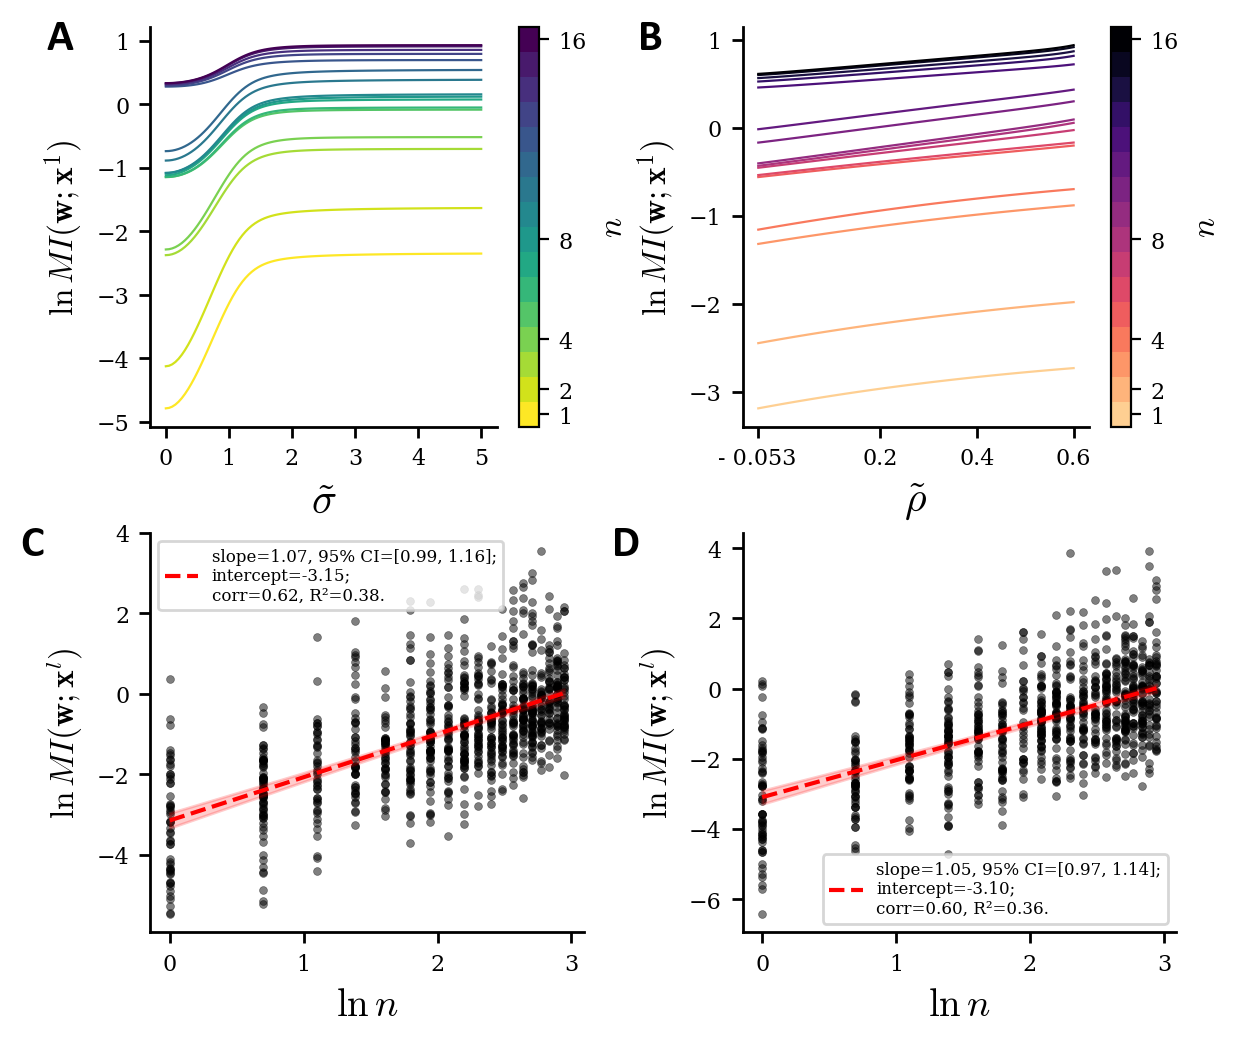

In [10]:
# Set up the plotting area
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(6, 5))
axes = axes.flatten()


#-------------------------- panel A ---------------------------------------------------

ax = axes[0]

# example list of connections for plotting, randomly picked
ws = [(2, 3), (4, 5), (2, 4), (2, 5), (6, 7), (8, 9), (3, 4), (3, 5), (10, 11), (12, 13),
      (14, 15), (2, 6), (4, 7), (16, 17), (18, 19), (3, 10)]

# Example data
x = np.linspace(0.001, 5, 100)
y = []

# Number of curves
num_curves = 16

# Generate a colormap with discrete colors
cmap = plt.get_cmap('viridis', num_curves).reversed()  # You can choose other colormaps like 'plasma', 'inferno', etc.

# Loop through different values of n (number of weights)
for n in range(1, 1 + num_curves):  # This will plot curves for n = 1, 2, ...,
    print(n)
    y = []
    w_list = ws[:n]
    for sigma in x:
        data = create_patterns_simple(10, 20, 1, sigma, 0.)
        MI = MI_nw_xl(data, w_list, 1)
        y.append(np.log(MI))
    ax.plot(x, y, label=f'number of connections={n}', color=cmap(n - 1), lw=0.8)

# Customize the axes
ax.spines['top'].set_visible(False)    # Remove top axis
ax.spines['right'].set_visible(False)  # Remove right axis

# Make left and bottom axes bolder
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

# Make the ticks on the left and bottom axes bolder and larger
ax.tick_params(axis='x', direction='out', length=4, width=1, labelsize=8)
ax.tick_params(axis='y', direction='out', length=4, width=1, labelsize=8)

# Add labels and title with larger font size
ax.set_xlabel(r'$\tilde{\sigma}$', fontsize=15)
ax.set_ylabel(r'$\ln MI(\mathbf{w}; \mathbf{x}^1)$', fontsize=12)

# control xtick
ax.set_xticks([0, 1, 2, 3, 4, 5])
#ax.set_xticklabels(['0', '1', '2', '3', '0.8', '1'])


# Create a colorbar
scm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0.5, vmax=num_curves+0.5))
scm.set_array([])  # Only needed for matplotlib < 3.1
cbar = plt.colorbar(scm, ax=ax, ticks=[1, 2, 4, 8, 16])
cbar.ax.tick_params(labelsize=8)
#cbar.ax.invert_yaxis()
cbar.set_label('$n$', fontsize=12)

# add panel letter
ax.text(
        -0.3, 1.02, 'A',
        transform=ax.transAxes,
        fontsize=16,
        fontname='Calibri',
        fontweight='bold',
        va='top',
        ha='left'
    )


# ------------------------------panel B -----------------------------------------------

ax = axes[1]

# the same list of connections, randomly picked
ws = [(2, 3), (4, 5), (2, 4), (2, 5), (6, 7), (8, 9), (3, 4), (3, 5), (10, 11), (12, 13),
      (14, 15), (2, 6), (4, 7), (16, 17), (18, 19), (3, 10)]

# Example data
x = np.linspace(-1 / 19 + 0.001, 0.6, 100)
y = []

# Number of curves
num_curves = 16

# Generate a colormap with 30 discrete colors
# You can choose other colormaps like 'plasma', 'inferno', etc.
base_cmap = plt.get_cmap('magma')
colors = base_cmap(np.linspace(0.0, 0.9, num_curves)) # build a new colormap that cuts the lightest part of magma
cmap = ListedColormap(colors[::-1])

# Loop through different values of n
for n in range(1, 1 + num_curves): # 1, 2 ... 15
    print(n, '------------')
    y = []
    w_list = ws[:n]
    for rho in x:
        data = create_patterns_simple(10, 20, 1, 1, rho)
        MI = MI_nw_xl(data, w_list, 1)
        y.append(np.log(MI))

    # Find the index of the first NaN in y, only plot till then
    nan_index = np.where(np.isnan(y))[0]

    if nan_index.size > 0:
        # Slice x and y up to the first NaN
        first_nan = nan_index[0]
        ax.plot(x[:first_nan], y[:first_nan], color=cmap(n - 1), lw=0.8)
    else:
        ax.plot(x, y, color=cmap(n - 1), lw=0.8)

# Customize the axes
ax.spines['top'].set_visible(False)    # Remove top axis
ax.spines['right'].set_visible(False)  # Remove right axis

# Make left and bottom axes bolder
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

# Make the ticks on the left and bottom axes bolder and larger
ax.tick_params(axis='x', direction='out', length=4, width=1, labelsize=8)
ax.tick_params(axis='y', direction='out', length=4, width=1, labelsize=8)


# add the negative part of xtick
ax.set_xticks([- 0.053, 0.2,  0.4,  0.6])
ax.set_xticklabels(['- 0.053', '0.2', '0.4', '0.6'])

# Add labels and title with larger font size
ax.set_xlabel(r'$\tilde{\rho}$', fontsize=15)
ax.set_ylabel(r'$\ln MI(\mathbf{w};\mathbf{x}^1)$', fontsize=12)

# Create a colorbar
scm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0.5, vmax=num_curves+0.5))
scm.set_array([])  # Only needed for matplotlib < 3.1
cbar = plt.colorbar(scm, ax=ax, ticks=[1, 2, 4, 8, 16])
cbar.ax.tick_params(labelsize=8)
cbar.set_label('$n$', fontsize=12)


# add panel letter
ax.text(
        -0.3, 1.02, 'B',
        transform=ax.transAxes,
        fontsize=16,
        fontname='Calibri',
        fontweight='bold',
        va='top',
        ha='left'
    )

# ------------------------ C   ------------------------------

ax = axes[2]

# Load the data from the CSV file
df = pd.read_csv(os.path.join(DATA_DIR, 'generated_samples_1000_covsame.csv'))


# Define the columns you want to analyze against MI
columns_to_analyze = ['n']
xlabel_names = ['n']
i=0
column='n'

# Log-transform the data
log_X = np.log(df[column].values)
log_Y = np.log(df['MI'].values)

# Scatter plot on log-log scale
sns.scatterplot(x=log_X, y=log_Y, ax=ax, s=8, color='black', alpha=0.5, edgecolor=None)

# Pearson correlation coefficient and its p-value on log-log scale
corr, p_value = pearsonr(log_X, log_Y)

# Linear regression using statsmodels
X = sm.add_constant(log_X)   # adds intercept term
Y = log_Y
model = sm.OLS(Y, X).fit()

# Extract regression results
intercept = model.params[0]
slope = model.params[1]
R2 = model.rsquared

# 95% CI for intercept and slope
conf_int = model.conf_int(alpha=0.05)
intercept_ci = conf_int[0]
slope_ci = conf_int[1]

print(f'{column}:')
print(f'  slope = {slope:.4f}, 95% CI = [{slope_ci[0]:.4f}, {slope_ci[1]:.4f}]')
print(f'  intercept = {intercept:.4f}, 95% CI = [{intercept_ci[0]:.4f}, {intercept_ci[1]:.4f}]')
print(f'  R² = {R2:.4f}')
print(f'  slope p-value = {model.pvalues[1]:.4e}')
print()

# Plot the regression line
X_pred = np.linspace(np.min(log_X), np.max(log_X), 100)
X_pred_with_const = sm.add_constant(X_pred)
Y_pred = model.predict(X_pred_with_const)

ax.plot(
    X_pred, Y_pred,
    color='red', linewidth=1.5, linestyle='--',
    label=(
        f'slope={slope:.2f}, 95% CI=[{slope_ci[0]:.2f}, {slope_ci[1]:.2f}];\n'
        f'intercept={intercept:.2f};\n'
        f'corr={corr:.2f}, R²={R2:.2f}.'
    )
)

pred = model.get_prediction(X_pred_with_const)
pred_ci = pred.conf_int()

ax.fill_between(
    X_pred,
    pred_ci[:,0],
    pred_ci[:,1],
    color='red',
    alpha=0.2
)

# Set titles and labels
ax.set_xlabel(fr'$\ln {xlabel_names[i]}$', fontsize=14)
ax.set_ylabel(r'$\ln MI(\mathbf{w};\mathbf{x}^l)$', fontsize=12)

# Add legend
leg = ax.legend(fontsize=6)
leg.set_in_layout(False)

# Improve the overall look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Make left and bottom axes bolder
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

# Make the ticks on the left and bottom axes bolder and larger
ax.tick_params(axis='x', direction='out', length=4, width=1, labelsize=8)
ax.tick_params(axis='y', direction='out', length=4, width=1, labelsize=8)

# add panel letter
ax.text(
        -0.3, 1.02, 'C',
        transform=ax.transAxes,
        fontsize=16,
        fontname='Calibri',
        fontweight='bold',
        va='top',
        ha='left'
    )


# ----------------------  D   --------------------------------

ax = axes[3]

# Load the data from the CSV file
df = pd.read_csv(os.path.join(DATA_DIR, 'generated_samples_1000_covdifferent_eigenmethod.csv'))


# Define the columns you want to analyze against MI
columns_to_analyze = ['n']
xlabel_names = ['n']
i=0
column='n'


# Log-transform the data
log_X = np.log(df[column].values)
log_Y = np.log(df['MI'].values)

# Scatter plot on log-log scale
sns.scatterplot(x=log_X, y=log_Y, ax=ax, s=8, color='black', alpha=0.5, edgecolor=None)

# Pearson correlation coefficient and its p-value on log-log scale
corr, p_value = pearsonr(log_X, log_Y)

# Linear regression using statsmodels
X = sm.add_constant(log_X)   # adds intercept term
Y = log_Y
model = sm.OLS(Y, X).fit()

# Extract regression results
intercept = model.params[0]
slope = model.params[1]
R2 = model.rsquared

# 95% CI for intercept and slope
conf_int = model.conf_int(alpha=0.05)
intercept_ci = conf_int[0]
slope_ci = conf_int[1]

print(f'{column}:')
print(f'  slope = {slope:.4f}, 95% CI = [{slope_ci[0]:.4f}, {slope_ci[1]:.4f}];')
print(f'  intercept = {intercept:.4f}, 95% CI = [{intercept_ci[0]:.4f}, {intercept_ci[1]:.4f}];')
print(f'  R² = {R2:.4f};')
print(f'  slope p-value = {model.pvalues[1]:.4e}.')
print()

# Plot the regression line
X_pred = np.linspace(np.min(log_X), np.max(log_X), 100)
X_pred_with_const = sm.add_constant(X_pred)
Y_pred = model.predict(X_pred_with_const)

ax.plot(
    X_pred, Y_pred,
    color='red', linewidth=1.5, linestyle='--',
    label=(
        f'slope={slope:.2f}, 95% CI=[{slope_ci[0]:.2f}, {slope_ci[1]:.2f}];\n'
        f'intercept={intercept:.2f};\n'
        f'corr={corr:.2f}, R²={R2:.2f}.'
    )
)

pred = model.get_prediction(X_pred_with_const)
pred_ci = pred.conf_int()

ax.fill_between(
    X_pred,
    pred_ci[:,0],
    pred_ci[:,1],
    color='red',
    alpha=0.2
)

# Set titles and labels
ax.set_xlabel(fr'$\ln {xlabel_names[i]}$', fontsize=14)
ax.set_ylabel(r'$\ln MI(\mathbf{w};\mathbf{x}^l)$', fontsize=12)

# Add legend
leg = ax.legend(fontsize=6)
leg.set_in_layout(False)

# Improve the overall look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Make left and bottom axes bolder
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

# Make the ticks on the left and bottom axes bolder and larger
ax.tick_params(axis='x', direction='out', length=4, width=1, labelsize=8)
ax.tick_params(axis='y', direction='out', length=4, width=1, labelsize=8)

# add panel letter
ax.text(
        -0.3, 1.02, 'D',
        transform=ax.transAxes,
        fontsize=16,
        fontname='Calibri',
        fontweight='bold',
        va='top',
        ha='left'
    )

# -----------------------------------------------

plt.tight_layout(pad=0.0, w_pad=0.00, h_pad=0.1)
#plt.tight_layout()
plt.show()
#plt.savefig("fig_3.pdf", bbox_inches="tight")